In [1]:
import pandas as pd
import numpy as np
import json
from catboost import CatBoostClassifier
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import QuantileTransformer
import warnings
import copy
from pathlib import Path
import os
import time
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Globals and Ratios (aligned with neural notebook)
# ---------------------------------------------------------------------------
RANDOM_STATE = 42

VARIANT_CONFIGS = {
    "full": {
        "suffix": "_full",
        "train": "df_train_full.csv",
        "final_ood": "df_test_full.csv",
    },
    "no_time_adv": {
        "suffix": "_no_time_adv",
        "train": "df_train_no_time_adv.csv",
        "final_ood": "df_test_no_time_adv.csv",
    },
    "no_student": {
        "suffix": "_no_student",
        "train": "df_train_no_student.csv",
        "final_ood": "df_test_no_student.csv",
    },
}

ACTIVE_VARIANT_NAME = "full"
DATA_SUFFIX = VARIANT_CONFIGS[ACTIVE_VARIANT_NAME]["suffix"]
TRAIN_FILENAME = VARIANT_CONFIGS[ACTIVE_VARIANT_NAME]["train"]
FINAL_OOD_FILENAME = VARIANT_CONFIGS[ACTIVE_VARIANT_NAME]["final_ood"]

TRAIN_RATIO = 4
VAL_RATIO = 1
INDIST_TEST_RATIO = 1
N_ROW_ORDER_DOMAINS = 6

QUANTILE_N_QUANTILES = 2048
QUANTILE_SUBSAMPLE = 200000

# VAE recon-loss fusion for OOD scoring (train-only, zero leakage)
# Fusing reconstruction loss provides temporal shift robustness
RECON_OOD_WEIGHT = 0.45

# Threshold selection floors
VAL_ATTACK_RECALL_FLOOR = 0.970
VAL_BENIGN_SPEC_FLOOR = 0.985
VAL_WORST_DOMAIN_BENIGN_FLOOR = 0.960
EPS = 1e-8

PROJECT_ROOT = Path.cwd()
KAGGLE_INPUT = Path('/kaggle/input')
KAGGLE_WORKING = Path('/kaggle/working')
OUTPUT_DIR = KAGGLE_WORKING if KAGGLE_WORKING.exists() else PROJECT_ROOT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR_CANDIDATES = [
    Path(os.environ['CIC_IDS_DATA_DIR']) if os.environ.get('CIC_IDS_DATA_DIR') else None,
    PROJECT_ROOT,
    PROJECT_ROOT / 'datasets',
    KAGGLE_INPUT,
    KAGGLE_INPUT / 'compressed-cic-2018',
    KAGGLE_WORKING,
]
DATA_DIR_CANDIDATES = [p for p in DATA_DIR_CANDIDATES if p is not None]

def find_data_file(filename: str) -> Path:
    for base in DATA_DIR_CANDIDATES:
        candidate = base / filename
        if candidate.exists():
            return candidate
    searched = '\n'.join(str(p / filename) for p in DATA_DIR_CANDIDATES)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")

def artifact_path(filename: str) -> Path:
    return OUTPUT_DIR / filename

def seed_everything(seed: int = RANDOM_STATE) -> None:
    np.random.seed(seed)

seed_everything()

# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------
def safe_divide(num: float, den: float) -> float:
    return float(num / den) if den else 0.0

def hierarchical_f1(y_true_internal: np.ndarray, y_pred_internal: np.ndarray) -> float:
    y_true_binary = (y_true_internal != 0).astype(np.int64)
    y_pred_binary = (y_pred_internal != 0).astype(np.int64)
    binary_f1 = f1_score(y_true_binary, y_pred_binary, average="macro", zero_division=0)
    subtype_mask = y_true_internal != 0
    if subtype_mask.any():
        subtype_f1 = f1_score(
            y_true_internal[subtype_mask],
            y_pred_internal[subtype_mask],
            average="macro",
            zero_division=0,
        )
    else:
        subtype_f1 = binary_f1
    return float(0.5 * binary_f1 + 0.5 * subtype_f1)

def binary_metrics(y_true_binary: np.ndarray, y_pred_binary: np.ndarray, score: np.ndarray | None = None) -> dict[str, float]:
    cm = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    precision, recall, f1_values, _ = precision_recall_fscore_support(
        y_true_binary,
        y_pred_binary,
        labels=[0, 1],
        zero_division=0,
    )
    metrics = {
        "bal_acc": float(balanced_accuracy_score(y_true_binary, y_pred_binary)),
        "macro_f1": float(f1_score(y_true_binary, y_pred_binary, average="macro", zero_division=0)),
        "benign_precision": float(precision[0]),
        "attack_precision": float(precision[1]),
        "benign_recall": float(recall[0]),
        "attack_recall": float(recall[1]),
        "benign_f1": float(f1_values[0]),
        "attack_f1": float(f1_values[1]),
        "benign_specificity": safe_divide(tn, tn + fp),
        "attack_rate": float(np.mean(y_pred_binary)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }
    if score is not None:
        metrics["score_mean"] = float(np.mean(score))
        metrics["score_p95"] = float(np.quantile(score, 0.95))
    return metrics

def multiclass_metrics(y_true_internal: np.ndarray, y_pred_internal: np.ndarray) -> dict[str, float]:
    num_classes = len(np.unique(y_true_internal))
    labels = list(range(num_classes))
    subtype_mask = y_true_internal != 0
    if subtype_mask.any():
        subtype_f1 = f1_score(
            y_true_internal[subtype_mask],
            y_pred_internal[subtype_mask],
            labels=labels[1:],
            average="macro",
            zero_division=0,
        )
    else:
        subtype_f1 = 0.0
    return {
        "bal_acc": float(balanced_accuracy_score(y_true_internal, y_pred_internal)),
        "macro_f1": float(f1_score(y_true_internal, y_pred_internal, labels=labels, average="macro", zero_division=0)),
        "hier_f1": hierarchical_f1(y_true_internal, y_pred_internal),
        "subtype_f1": float(subtype_f1),
    }

def ood_unseen_recall(
    original_labels: np.ndarray,
    y_pred_binary: np.ndarray,
    known_labels: list[int] | None = None,
) -> float:
    reference_labels = known_attack_labels if known_labels is None else known_labels
    unseen_mask = (original_labels != 0) & ~np.isin(original_labels, np.array(reference_labels, dtype=np.int64))
    if not unseen_mask.any():
        return float("nan")
    return float(np.mean(y_pred_binary[unseen_mask] == 1))


/mnt/c/users/vihaa/OneDrive/Documents/IPD-IDS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------------------------
# Loading, 3-Way Splitting, and Domain Mapping (clean of test set)
# ---------------------------------------------------------------------------
def load_train_variant(variant_name: str) -> pd.DataFrame:
    config = VARIANT_CONFIGS[variant_name]
    path = find_data_file(config["train"])
    print(f"Loading train variant {variant_name!r} from {path.name}...")
    return pd.read_csv(path)

def stratified_three_way_split(
    labels: np.ndarray,
    train_ratio: int,
    val_ratio: int,
    test_ratio: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    train_idx: list[np.ndarray] = []
    val_idx: list[np.ndarray] = []
    test_idx: list[np.ndarray] = []
    total_ratio = train_ratio + val_ratio + test_ratio

    for label in np.sort(np.unique(labels)):
        idx = np.flatnonzero(labels == label)
        rng.shuffle(idx)
        n = len(idx)
        n_test = max(1, int(round(n * test_ratio / total_ratio)))
        n_val = max(1, int(round(n * val_ratio / total_ratio)))
        if n_test + n_val >= n:
            n_test = max(1, n // 6)
            n_val = max(1, n // 6)
        test_idx.append(idx[:n_test])
        val_idx.append(idx[n_test : n_test + n_val])
        train_idx.append(idx[n_test + n_val :])

    return (
        np.sort(np.concatenate(train_idx)),
        np.sort(np.concatenate(val_idx)),
        np.sort(np.concatenate(test_idx)),
    )

def build_label_mapping(labels: pd.Series) -> tuple[dict[int, int], dict[int, int], list[int]]:
    original_labels = sorted(int(v) for v in labels.unique())
    if 0 not in original_labels:
        raise ValueError("Benign label 0 is required for the binary OOD task.")
    attack_labels = [v for v in original_labels if v != 0]
    original_to_internal = {0: 0}
    for internal_id, original_id in enumerate(attack_labels, start=1):
        original_to_internal[original_id] = internal_id
    internal_to_original = {v: k for k, v in original_to_internal.items()}
    return original_to_internal, internal_to_original, attack_labels

def map_labels(series: pd.Series, original_to_internal: dict[int, int]) -> np.ndarray:
    mapped = series.map(original_to_internal)
    if mapped.isna().any():
        missing = sorted(int(v) for v in series[mapped.isna()].unique())
        raise ValueError(f"Training split contains labels missing from mapping: {missing}")
    return np.ascontiguousarray(mapped.to_numpy(dtype=np.int64, copy=True))

def take_split(frame: pd.DataFrame, indices: np.ndarray) -> pd.DataFrame:
    out = frame.iloc[indices].copy()
    out["_source_row"] = indices.astype(np.int64)
    return out.reset_index(drop=True)

def row_order_domains(frame: pd.DataFrame) -> np.ndarray:
    if "_source_row" not in frame.columns:
        raise ValueError("Expected '_source_row' in train-derived frames.")
    raw = frame["_source_row"].to_numpy(dtype=np.float64)
    domain = np.floor(raw * N_ROW_ORDER_DOMAINS / max(1, TOTAL_SOURCE_ROWS)).astype(np.int64)
    return np.ascontiguousarray(np.clip(domain, 0, N_ROW_ORDER_DOMAINS - 1))

def activate_variant(variant_name: str, force_reload: bool = False) -> None:
    global ACTIVE_VARIANT_NAME, DATA_SUFFIX, TRAIN_FILENAME, FINAL_OOD_FILENAME
    global df_train, df_val, df_indist_test, original_to_internal, internal_to_original
    global known_attack_labels, num_classes, num_attack_classes, TOTAL_SOURCE_ROWS

    if (
        not force_reload
        and globals().get("ACTIVE_VARIANT_NAME") == variant_name
        and "df_train" in globals()
        and "df_val" in globals()
        and "df_indist_test" in globals()
    ):
        print(f"variant already active: {variant_name}")
        return

    config = VARIANT_CONFIGS[variant_name]
    ACTIVE_VARIANT_NAME = variant_name
    DATA_SUFFIX = config["suffix"]
    TRAIN_FILENAME = config["train"]
    FINAL_OOD_FILENAME = config["final_ood"]

    df_all_variant = load_train_variant(variant_name)
    original_to_internal, internal_to_original, known_attack_labels = build_label_mapping(df_all_variant["label"])
    num_classes = len(original_to_internal)
    num_attack_classes = max(1, num_classes - 1)
    TOTAL_SOURCE_ROWS = int(len(df_all_variant))
    train_idx, val_idx, indist_test_idx = stratified_three_way_split(
        df_all_variant["label"].to_numpy(),
        TRAIN_RATIO,
        VAL_RATIO,
        INDIST_TEST_RATIO,
        RANDOM_STATE,
    )

    df_train = take_split(df_all_variant, train_idx)
    df_val = take_split(df_all_variant, val_idx)
    df_indist_test = take_split(df_all_variant, indist_test_idx)
    del df_all_variant

    print(f"known attack labels={known_attack_labels}")
    print(f"internal class map={original_to_internal}")
    print(f"split rows | train={len(df_train):,} val={len(df_val):,} in_dist_test={len(df_indist_test):,}")

activate_variant("full")


Train path: /mnt/c/users/vihaa/OneDrive/Documents/IPD-IDS/df_train.csv
Test path: /mnt/c/users/vihaa/OneDrive/Documents/IPD-IDS/df_test.csv
Train shape: (2049029, 8)
Test shape: (1048575, 8)

Train label distribution:
label
0    1663709
4     187587
3     145241
1      41508
2      10984
Name: count, dtype: int64

Test label distribution:
label
8    686012
0    360833
9      1730
Name: count, dtype: int64


In [ ]:
# ---------------------------------------------------------------------------
# Feature Column setup & Preprocessing / Reconstruction Scoring Helpers
# ---------------------------------------------------------------------------
def refresh_feature_sets() -> dict[str, list[str]]:
    latent_cols = [c for c in df_train.columns if c.startswith('latent_')]
    loss_cols = []
    if 'student_loss' in df_train.columns:
        loss_cols.append('student_loss')
    elif 'recon_loss' in df_train.columns:
        loss_cols.append('recon_loss')
    if 'mse_loss' in df_train.columns:
        loss_cols.append('mse_loss')
    if 'kld_loss' in df_train.columns:
        loss_cols.append('kld_loss')
    
    all_cols = list(df_train.columns)
    ignored = ["label", "_source_row"]
    original_cols = [c for c in all_cols if c not in ignored]
    
    return {
        "compressed + losses": latent_cols + loss_cols,
        "compressed only": latent_cols,
        "full dataset": original_cols,
    }

def clean_float32(frame: pd.DataFrame, columns: list[str]) -> np.ndarray:
    values = frame[columns].replace([np.inf, -np.inf], np.nan).to_numpy(dtype=np.float32)
    med = np.nanmedian(values, axis=0).astype(np.float32)
    bad = ~np.isfinite(values)
    if bad.any():
        values[bad] = np.take(med, np.where(bad)[1])
    return values.astype(np.float32, copy=False)

def fit_feature_scaler(x_train_raw: np.ndarray) -> QuantileTransformer:
    n_quantiles = min(QUANTILE_N_QUANTILES, max(10, len(x_train_raw)))
    subsample = min(QUANTILE_SUBSAMPLE, len(x_train_raw))
    scaler = QuantileTransformer(
        n_quantiles=n_quantiles,
        output_distribution="normal",
        subsample=subsample,
        random_state=RANDOM_STATE,
        copy=True,
    )
    scaler.fit(x_train_raw)
    return scaler

def transform_features(scaler: QuantileTransformer, x_raw: np.ndarray) -> np.ndarray:
    x = np.asarray(scaler.transform(x_raw), dtype=np.float32).copy()
    np.clip(x, -5.0, 5.0, out=x)
    return np.ascontiguousarray(x)

def _extract_recon_cols(frame: pd.DataFrame, feature_columns: list[str]) -> np.ndarray | None:
    wanted = ["mse_loss", "kld_loss"]
    cols = [c for c in wanted if c in feature_columns and c in frame.columns]
    if not cols:
        return None
    return frame[cols].to_numpy(dtype=np.float32)

def fit_recon_scorer(recon_train: np.ndarray) -> dict:
    p5 = np.percentile(recon_train, 5, axis=0).astype(np.float32)
    p95 = np.percentile(recon_train, 95, axis=0).astype(np.float32)
    return {"p5": p5, "p95": p95}

def score_recon(rs: dict, recon_vals: np.ndarray) -> np.ndarray:
    span = np.maximum(rs["p95"] - rs["p5"], EPS)
    scaled = (recon_vals - rs["p5"]) / span
    raw = np.clip(scaled.mean(axis=1), 0.0, None)
    return np.clip(1.0 - np.exp(-raw), 0.0, 1.0).astype(np.float32)

def binary_attack_score(
    proba_benign: np.ndarray,
    recon_scorer: dict | None = None,
    recon_vals: np.ndarray | None = None,
) -> np.ndarray:
    base = np.clip(1.0 - proba_benign, 0.0, 1.0).astype(np.float32)
    if recon_scorer is None or recon_vals is None or RECON_OOD_WEIGHT <= 0.0:
        return base
    recon_score = score_recon(recon_scorer, recon_vals)
    w = float(RECON_OOD_WEIGHT)
    return np.clip((1.0 - w) * base + w * recon_score, 0.0, 1.0).astype(np.float32)

def class_predictions(attack_subtype_prob: np.ndarray, attack_score: np.ndarray, threshold: float) -> np.ndarray:
    pred = np.zeros(len(attack_score), dtype=np.int64)
    attack_mask = attack_score >= threshold
    if attack_mask.any():
        pred[attack_mask] = 1 + np.argmax(attack_subtype_prob[attack_mask], axis=1)
    return pred

feature_sets = refresh_feature_sets()
feature_cols = feature_sets["compressed + losses"]


X_train_full: (2049029, 7), X_test: (1048575, 7)

Class distribution in training:
  Class 0: 1663709 samples, weight: 0.2463
  Class 1: 41508 samples, weight: 9.8729
  Class 2: 10984 samples, weight: 37.3093
  Class 3: 145241 samples, weight: 2.8216
  Class 4: 187587 samples, weight: 2.1846


# Optuna Hyperparameter Tuning

In [4]:
# ---------------------------------------------------------------------------
# Optuna Hyperparameter Tuning (train split vs val split, GPU optimized)
# ---------------------------------------------------------------------------
def tune_catboost(X_train, y_train, X_val, y_val, n_trials=8) -> optuna.study.Study:
    sw_train = compute_sample_weight(class_weight='balanced', y=y_train)

    def objective(trial):
        params = {
            'loss_function': 'MultiClass',
            'task_type': 'GPU',
            'verbose': False,
            'random_state': RANDOM_STATE,
            'border_count': 64,
            # Constrain parameters to avoid in-distribution overfitting and allow OOD generalization
            'iterations': trial.suggest_int('iterations', 100, 400),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'depth': trial.suggest_int('depth', 4, 6),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 1000, log=True),
        }
        model = CatBoostClassifier(**params)
        model.fit(
            X_train, y_train,
            sample_weight=sw_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=30
        )
        y_pred = model.predict(X_val).ravel()
        return hierarchical_f1(y_val, y_pred)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    # Optuna runs sequentially to safely manage VRAM on the GPU
    study.optimize(objective, n_trials=n_trials, n_jobs=1, catch=(Exception,))
    return study

X_train = clean_float32(df_train, feature_cols)
y_train = map_labels(df_train["label"], original_to_internal)
X_val = clean_float32(df_val, feature_cols)
y_val = map_labels(df_val["label"], original_to_internal)

study = tune_catboost(X_train, y_train, X_val, y_val, n_trials=8)
print(f"\nBest trial hierarchical F1: {study.best_trial.value:.4f}")
print(f"Best params: {study.best_trial.params}")


[I 2026-05-17 14:01:39,246] A new study created in memory with name: no-name-9036e768-9b29-444f-9add-8b6f3d09a964
Best trial: 0. Best value: 0.615647:   5%|▌         | 1/20 [00:50<15:51, 50.08s/it]

[I 2026-05-17 14:02:29,325] Trial 0 finished with value: 0.6156473960036207 and parameters: {'iterations': 558, 'learning_rate': 0.15301617367477185, 'depth': 9, 'l2_leaf_reg': 6.839457528958894e-08, 'min_data_in_leaf': 5}. Best is trial 0 with value: 0.6156473960036207.


Best trial: 1. Best value: 0.633813:  10%|█         | 2/20 [01:23<12:08, 40.45s/it]

[I 2026-05-17 14:03:03,032] Trial 1 finished with value: 0.633813351473864 and parameters: {'iterations': 512, 'learning_rate': 0.008896193013446385, 'depth': 10, 'l2_leaf_reg': 0.00022733392036071144, 'min_data_in_leaf': 3}. Best is trial 1 with value: 0.633813351473864.


Best trial: 1. Best value: 0.633813:  15%|█▌        | 3/20 [01:42<08:42, 30.72s/it]

...

[I 2026-05-17 14:28:26,478] Trial 17 finished with value: 0.6517310166819217 and parameters: {'iterations': 652, 'learning_rate': 0.29292943364898333, 'depth': 7, 'l2_leaf_reg': 0.002301052730188545, 'min_data_in_leaf': 2}. Best is trial 13 with value: 0.7364136319968556.


Best trial: 13. Best value: 0.736414:  95%|█████████▌| 19/20 [31:04<02:50, 170.11s/it]

[I 2026-05-17 14:32:43,304] Trial 18 finished with value: 0.7225372760657214 and parameters: {'iterations': 987, 'learning_rate': 0.045310593669335514, 'depth': 5, 'l2_leaf_reg': 0.8368513966577236, 'min_data_in_leaf': 7}. Best is trial 13 with value: 0.7364136319968556.


Best trial: 13. Best value: 0.736414: 100%|██████████| 20/20 [31:30<00:00, 94.53s/it] 

[I 2026-05-17 14:33:09,920] Trial 19 finished with value: 0.5678084485559534 and parameters: {'iterations': 602, 'learning_rate': 0.015909075278730346, 'depth': 5, 'l2_leaf_reg': 9.53513810734389e-05, 'min_data_in_leaf': 2}. Best is trial 13 with value: 0.7364136319968556.

Best trial hierarchical F1: 0.7364
Best params: {'iterations': 743, 'learning_rate': 0.2835813890997382, 'depth': 6, 'l2_leaf_reg': 0.09849896900025777, 'min_data_in_leaf': 2}


# Train Final Model with Best Params

In [5]:
# ---------------------------------------------------------------------------
# Train Final Model with Best Params and Select Decision Threshold
# ---------------------------------------------------------------------------
best_params = study.best_trial.params.copy()
best_params.update({
    'loss_function': 'MultiClass',
    'task_type': 'GPU',
    'verbose': False,
    'random_state': RANDOM_STATE,
})

final_model = CatBoostClassifier(**best_params)
sw_train = compute_sample_weight(class_weight='balanced', y=y_train)
final_model.fit(X_train, y_train, sample_weight=sw_train, eval_set=(X_val, y_val), early_stopping_rounds=30)

# Fit VAE reconstruction scorer
recon_train = _extract_recon_cols(df_train, feature_cols)
if recon_train is not None:
    recon_scorer = fit_recon_scorer(recon_train)
    recon_val = _extract_recon_cols(df_val, feature_cols)
    print(f"  recon_scorer | p5={recon_scorer['p5'].tolist()} | p95={recon_scorer['p95'].tolist()}")
else:
    recon_scorer = None
    recon_val = None

# Open-world Threshold selection on val split
proba_val = final_model.predict_proba(X_val)
score_val = binary_attack_score(proba_val[:, 0], recon_scorer, recon_val)
domain_val = row_order_domains(df_val)

def worst_domain_benign_recall(y_binary: np.ndarray, y_pred_binary: np.ndarray, domain_id: np.ndarray | None) -> float:
    if domain_id is None:
        return float(binary_metrics(y_binary, y_pred_binary)["benign_recall"])
    recalls: list[float] = []
    for domain in np.sort(np.unique(domain_id)):
        mask = (domain_id == domain) & (y_binary == 0)
        if mask.any():
            recalls.append(float(np.mean(y_pred_binary[mask] == 0)))
    return float(min(recalls)) if recalls else 0.0

def choose_open_world_threshold(
    score: np.ndarray,
    y_internal: np.ndarray,
    domain_id: np.ndarray | None = None,
) -> tuple[float, dict[str, float]]:
    y_binary = (y_internal != 0).astype(np.int64)
    if len(np.unique(y_binary)) != 2:
        raise ValueError("Validation split needs both benign and attack rows for threshold selection.")

    quantiles = np.linspace(0.001, 0.999, 600)
    candidate_thresholds = np.unique(
        np.concatenate(
            [
                np.quantile(score, quantiles),
                np.linspace(0.02, 0.98, 250),
            ]
        )
    )

    is_attack = (y_binary == 1)
    is_benign = (y_binary == 0)
    n_attack = np.sum(is_attack)
    n_benign = np.sum(is_benign)

    score_col = score[:, np.newaxis]
    thresh_row = candidate_thresholds[np.newaxis, :]
    pred_matrix = (score_col >= thresh_row)

    tp = np.sum(pred_matrix[is_attack, :], axis=0)
    fp = np.sum(pred_matrix[is_benign, :], axis=0)

    fn = n_attack - tp
    tn = n_benign - fp

    attack_recall = tp / n_attack
    benign_specificity = tn / n_benign

    denom_bp = tn + fn
    benign_precision = np.zeros_like(tn, dtype=np.float32)
    nz_bp = denom_bp > 0
    benign_precision[nz_bp] = tn[nz_bp] / denom_bp[nz_bp]

    denom_ap = tp + fp
    attack_precision = np.zeros_like(tp, dtype=np.float32)
    nz_ap = denom_ap > 0
    attack_precision[nz_ap] = tp[nz_ap] / denom_ap[nz_ap]

    benign_f1 = np.zeros_like(tn, dtype=np.float32)
    denom_bf1 = benign_precision + benign_specificity
    nz_bf1 = denom_bf1 > 0
    benign_f1[nz_bf1] = 2.0 * benign_precision[nz_bf1] * benign_specificity[nz_bf1] / denom_bf1[nz_bf1]

    attack_f1 = np.zeros_like(tp, dtype=np.float32)
    denom_af1 = attack_precision + attack_recall
    nz_af1 = denom_af1 > 0
    attack_f1[nz_af1] = 2.0 * attack_precision[nz_af1] * attack_recall[nz_af1] / denom_af1[nz_af1]

    bal_acc = 0.5 * (attack_recall + benign_specificity)
    macro_f1 = 0.5 * (benign_f1 + attack_f1)

    if domain_id is None:
        worst_benign = benign_specificity
    else:
        unique_domains = np.sort(np.unique(domain_id))
        recalls_by_domain = []
        for domain in unique_domains:
            domain_mask = (domain_id == domain) & is_benign
            if domain_mask.any():
                n_benign_d = np.sum(domain_mask)
                tn_d = np.sum(~pred_matrix[domain_mask, :], axis=0)
                recalls_by_domain.append(tn_d / n_benign_d)
        if recalls_by_domain:
            worst_benign = np.minimum.reduce(recalls_by_domain)
        else:
            worst_benign = np.zeros(len(candidate_thresholds), dtype=np.float32)

    guarded_core = np.minimum(np.minimum(attack_recall, benign_specificity), worst_benign)
    min_spec_worst = np.minimum(benign_specificity, worst_benign)

    utility = (
        0.42 * bal_acc
        + 0.22 * macro_f1
        + 0.18 * attack_recall
        + 0.18 * min_spec_worst
        + 1e-4 * candidate_thresholds
    )

    any_key = utility + 0.10 * guarded_core + 0.05 * candidate_thresholds

    guarded_mask = (
        (attack_recall >= VAL_ATTACK_RECALL_FLOOR)
        & (benign_specificity >= VAL_BENIGN_SPEC_FLOOR)
        & (worst_benign >= VAL_WORST_DOMAIN_BENIGN_FLOOR)
    )

    guarded_key = utility + 0.25 * guarded_core + 0.12 * candidate_thresholds

    best_any_idx = np.argmax(any_key)

    if np.any(guarded_mask):
        masked_guarded_key = np.where(guarded_mask, guarded_key, -np.inf)
        best_idx = np.argmax(masked_guarded_key)
        source = "in_dist_val_domain_guarded"
    else:
        best_idx = best_any_idx
        source = "in_dist_val_domain_guarded_relaxed"

    threshold = float(candidate_thresholds[best_idx])

    metrics = {
        "bal_acc": float(bal_acc[best_idx]),
        "macro_f1": float(macro_f1[best_idx]),
        "benign_precision": float(benign_precision[best_idx]),
        "attack_precision": float(attack_precision[best_idx]),
        "benign_recall": float(benign_specificity[best_idx]),
        "attack_recall": float(attack_recall[best_idx]),
        "benign_f1": float(benign_f1[best_idx]),
        "attack_f1": float(attack_f1[best_idx]),
        "benign_specificity": float(benign_specificity[best_idx]),
        "worst_domain_benign_recall": float(worst_benign[best_idx]),
        "threshold": float(threshold),
        "attack_rate": float(np.mean(score >= threshold)),
        "tn": int(tn[best_idx]),
        "fp": int(fp[best_idx]),
        "fn": int(fn[best_idx]),
        "tp": int(tp[best_idx]),
        "score_mean": float(np.mean(score)),
        "score_p95": float(np.quantile(score, 0.95)),
        "threshold_source": source,
    }

    return float(threshold), metrics

threshold, thr_m = choose_open_world_threshold(score_val, y_val, domain_val)
print(f"Chosen threshold: {threshold:.4f} via {thr_m['threshold_source']}")
print(f"Val stats: recall={thr_m['attack_recall']:.4f}, benign_spec={thr_m['benign_specificity']:.4f}")


0:	learn: 0.9456201	total: 1.51s	remaining: 18m 39s
1:	learn: 0.7150472	total: 1.52s	remaining: 9m 24s
2:	learn: 0.5827539	total: 1.54s	remaining: 6m 19s
3:	learn: 0.4942322	total: 1.55s	remaining: 4m 46s
4:	learn: 0.4275540	total: 1.6s	remaining: 3m 55s
5:	learn: 0.3822664	total: 1.64s	remaining: 3m 21s
6:	learn: 0.3451209	total: 1.68s	remaining: 2m 56s
7:	learn: 0.3143148	total: 1.7s	remaining: 2m 36s
8:	learn: 0.2919083	total: 1.74s	remaining: 2m 21s
9:	learn: 0.2742249	total: 1.78s	remaining: 2m 10s
10:	learn: 0.2586618	total: 1.82s	remaining: 2m 1s
11:	learn: 0.2473538	total: 1.85s	remaining: 1m 53s
12:	learn: 0.2329533	total: 1.88s	remaining: 1m 45s
13:	learn: 0.2243923	total: 1.91s	remaining: 1m 39s
14:	learn: 0.2152358	total: 1.94s	remaining: 1m 33s
15:	learn: 0.2091332	total: 1.95s	remaining: 1m 28s
16:	learn: 0.2005200	total: 1.97s	remaining: 1m 24s
17:	learn: 0.1940692	total: 2.01s	remaining: 1m 20s
18:	learn: 0.1871564	total: 2.03s	remaining: 1m 17s
19:	learn: 0.1835756	tot

# Final Evaluation on Test Set

In [6]:
# ---------------------------------------------------------------------------
# Evaluate on In-Distribution Test Split
# ---------------------------------------------------------------------------
X_indist_test = clean_float32(df_indist_test, feature_cols)
y_indist_test = map_labels(df_indist_test["label"], original_to_internal)
recon_indist_test = _extract_recon_cols(df_indist_test, feature_cols)

proba_test = final_model.predict_proba(X_indist_test)
score_test = binary_attack_score(proba_test[:, 0], recon_scorer, recon_indist_test)

y_pred_indist = class_predictions(proba_test[:, 1:], score_test, threshold)

# Calculate and display metrics
print("=" * 60)
print("IN-DISTRIBUTION TEST SPLIT EVALUATION")
print("=" * 60)

y_pred_binary = (y_pred_indist != 0).astype(int)
y_true_binary = (y_indist_test != 0).astype(int)

sample_weights_binary = compute_sample_weight(class_weight='balanced', y=y_true_binary)
correct_mask = y_true_binary == y_pred_binary
benign_mask = y_true_binary == 0
attack_mask = y_true_binary == 1

benign_correct_weighted = np.sum(sample_weights_binary[benign_mask & correct_mask])
benign_total_weighted = np.sum(sample_weights_binary[benign_mask])
attack_correct_weighted = np.sum(sample_weights_binary[attack_mask & correct_mask])
attack_total_weighted = np.sum(sample_weights_binary[attack_mask])
total_correct_weighted = benign_correct_weighted + attack_correct_weighted
total_weighted = np.sum(sample_weights_binary)

print(f"Accuracy (binary): {accuracy_score(y_true_binary, y_pred_binary):.4f}")
print(f"  Benign weighted acc: {benign_correct_weighted/benign_total_weighted:.4f}")
print(f"  Attack weighted acc: {attack_correct_weighted/attack_total_weighted:.4f}")
print(f"Accuracy (binary weighted): {total_correct_weighted / total_weighted:.4f}")
print(f"Hierarchical F1: {hierarchical_f1(y_indist_test, y_pred_indist):.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (Binary: Attack vs Benign)")
print("=" * 60)
print(classification_report(y_true_binary, y_pred_binary, target_names=['Benign', 'Attack']))


FINAL TEST SET EVALUATION

Binary test distribution: Benign=360833, Attack=687742
Binary weights: Benign=1.4530, Attack=0.7623

Accuracy (multiclass):  0.3435
Accuracy (multiclass weighted): 0.3327
Accuracy (binary): 0.3747

Weighted Binary Evaluation (Attack vs Benign):
  Benign (0) weighted acc: 523347.41/524287.50 = 0.9982
  Attack (1) weighted acc: 24949.59/524287.50 = 0.0476
Accuracy (binary weighted): 0.5229

Hierarchical F1: 0.0000
Precision (macro): 0.0710
Recall (macro): 0.1996

CLASSIFICATION REPORT (Binary: Attack vs Benign)
              precision    recall  f1-score   support

      Benign       0.35      1.00      0.52    360833
      Attack       0.98      0.05      0.09    687742

    accuracy                           0.37   1048575
   macro avg       0.67      0.52      0.31   1048575
weighted avg       0.77      0.37      0.24   1048575



In [7]:
# ---------------------------------------------------------------------------
# Save Model and Threshold Parameters
# ---------------------------------------------------------------------------
import gc
gc.collect()

model_path = artifact_path('catboost_model.json')
final_model.save_model(str(model_path), format='json')
print(f'Model saved to {model_path}')

# Save thresholds and recon parameters for validation / inference
thresholds_dict = {
    'threshold': threshold,
    'recon_scorer': recon_scorer,
    'feature_cols': feature_cols
}
joblib.dump(thresholds_dict, artifact_path('anomaly_thresholds.joblib'))
print("Threshold config saved.")


Model saved to /mnt/c/users/vihaa/OneDrive/Documents/IPD-IDS/catboost_model.json


In [8]:
# ---------------------------------------------------------------------------
# Benchmark helpers: tuning functions and shared state
# ---------------------------------------------------------------------------
import gc
import time

experiment_results = {}
ood_rows = []
mc_rows = []
benchmark_models = {}

def evaluate_frame(
    bundle: dict[str, object],
    frame: pd.DataFrame,
    mode: str,
    original_label_for_unseen: bool = False,
) -> tuple[dict[str, float], dict[str, float] | None]:
    feature_columns = bundle["feature_columns"]
    model = bundle["model"]
    threshold = float(bundle["threshold"])
    recon_scorer = bundle.get("recon_scorer")
    original_to_internal = bundle["original_to_internal"]

    X_raw = clean_float32(frame, feature_columns)
    recon_vals = _extract_recon_cols(frame, feature_columns)

    proba = model.predict_proba(X_raw)
    score = binary_attack_score(proba[:, 0], recon_scorer, recon_vals)

    y_pred_internal = class_predictions(proba[:, 1:], score, threshold)
    y_pred_binary = (y_pred_internal != 0).astype(np.int64)

    y_true_binary = (frame["label"].to_numpy(dtype=np.int64) != 0).astype(np.int64)
    bin_result = binary_metrics(y_true_binary, y_pred_binary, score)
    bin_result["threshold"] = threshold
    bin_result["mode"] = mode
    bin_result["rows"] = int(len(frame))

    if original_label_for_unseen:
        known_labels = bundle["known_attack_labels"]
        bin_result["unseen_recall"] = ood_unseen_recall(
            frame["label"].to_numpy(dtype=np.int64), y_pred_binary, known_labels
        )

    mc_result = None
    if mode == "in_dist":
        y_true_internal = map_labels(frame["label"], original_to_internal)
        mc_result = multiclass_metrics(y_true_internal, y_pred_internal)
        mc_result["mode"] = mode
        mc_result["rows"] = int(len(frame))

    return bin_result, mc_result

def run_final_ood_evaluation(bundle: dict[str, object]) -> dict[str, float]:
    final_ood_filename = str(bundle["final_ood_filename"])
    final_ood_path = find_data_file(final_ood_filename)
    df_final_ood = pd.read_csv(final_ood_path)
    result, _ = evaluate_frame(bundle, df_final_ood, mode="final_ood", original_label_for_unseen=True)
    del df_final_ood
    return result

def train_one_model(feature_columns: list[str]) -> dict[str, object]:
    x_train_raw = clean_float32(df_train, feature_columns)
    x_val_raw = clean_float32(df_val, feature_columns)
    y_train = map_labels(df_train["label"], original_to_internal)
    y_val = map_labels(df_val["label"], original_to_internal)
    domain_val = row_order_domains(df_val)

    recon_train = _extract_recon_cols(df_train, feature_columns)
    if recon_train is not None:
        recon_scorer = fit_recon_scorer(recon_train)
        recon_val = _extract_recon_cols(df_val, feature_columns)
    else:
        recon_scorer = None
        recon_val = None

    print(f"Tuning hyperparameters on train split...")
    study = tune_catboost(x_train_raw, y_train, x_val_raw, y_val, n_trials=8)
    best_params = study.best_trial.params.copy()
    best_params.update({
        'loss_function': 'MultiClass',
        'task_type': 'GPU',
        'verbose': False,
        'random_state': RANDOM_STATE,
    })

    model = CatBoostClassifier(**best_params)
    sw_train = compute_sample_weight(class_weight='balanced', y=y_train)
    model.fit(x_train_raw, y_train, sample_weight=sw_train, eval_set=(x_val_raw, y_val), early_stopping_rounds=30)

    proba_val = model.predict_proba(x_val_raw)
    score_val = binary_attack_score(proba_val[:, 0], recon_scorer, recon_val)
    threshold, thr_m = choose_open_world_threshold(score_val, y_val, domain_val)

    return {
        "model": model,
        "threshold": threshold,
        "threshold_metrics": thr_m,
        "feature_columns": feature_columns,
        "original_to_internal": dict(original_to_internal),
        "known_attack_labels": list(known_attack_labels),
        "recon_scorer": recon_scorer,
        "final_ood_filename": FINAL_OOD_FILENAME,
    }

def run_feature_set(variant_name: str, feature_set_name: str, experiment_name: str) -> dict[str, object]:
    activate_variant(variant_name)
    feature_sets = refresh_feature_sets()
    if feature_set_name not in feature_sets:
        raise KeyError(f"Feature set {feature_set_name!r} is unavailable.")
    feature_columns = feature_sets[feature_set_name]

    print("=" * 80)
    print(f"MAIN/ABLATION RUN: {experiment_name}")
    print(f"variant={variant_name} | feature_set={feature_set_name} | columns={feature_columns}")

    fit_start = time.time()
    bundle = train_one_model(feature_columns)
    fit_seconds = time.time() - fit_start

    ood_metrics = run_final_ood_evaluation(bundle)
    indist_binary, indist_mc = evaluate_frame(bundle, df_indist_test, mode="in_dist")
    if indist_mc is None:
         raise RuntimeError("Expected multiclass metrics.")

    common = {
        "experiment": experiment_name,
        "variant": variant_name,
        "feature_set": feature_set_name,
        "train_file": TRAIN_FILENAME,
        "final_ood_file": FINAL_OOD_FILENAME,
        "n_features": len(feature_columns),
    }
    
    ood_metrics.update(common)
    indist_mc.update(common)
    indist_binary.update({f"in_dist_{k}": v for k, v in common.items()})
    
    ood_rows.append(ood_metrics)
    mc_rows.append(indist_mc)
    
    print(
        f"  [OOD binary]  bal_acc={ood_metrics['bal_acc']:.4f}  macro_f1={ood_metrics['macro_f1']:.4f}  "
        f"attack_recall={ood_metrics['attack_recall']:.4f}  benign_spec={ood_metrics['benign_specificity']:.4f}  "
        f"unseen_recall={ood_metrics.get('unseen_recall', float('nan')):.4f}  threshold={ood_metrics['threshold']:.3f}  "
        f"attack_rate={ood_metrics['attack_rate']:.3f}"
    )
    print(
        f"  [MC in-dist]  bal_acc={indist_mc['bal_acc']:.4f}  hier_f1={indist_mc['hier_f1']:.4f}  "
        f"subtype_f1={indist_mc['subtype_f1']:.4f}  macro_f1={indist_mc['macro_f1']:.4f}"
    )

    benchmark_models[experiment_name] = bundle["model"]
    experiment_results[experiment_name] = bundle
    
    return bundle


In [ ]:
# Run full variant with compressed + losses and compressed only feature sets
compressed_loss_bundle = run_feature_set(
    variant_name="full",
    feature_set_name="compressed + losses",
    experiment_name="full__compressed_plus_losses",
)

compressed_latent_bundle = run_feature_set(
    variant_name="full",
    feature_set_name="compressed only",
    experiment_name="full__compressed_only",
)


BENCHMARK: compressed + recon/kld loss (using pre-trained final model)
Test shape: (1048575, 7)

FINAL TEST SET EVALUATION

Binary test distribution: Benign=360833, Attack=687742
Binary weights: Benign=1.4530, Attack=0.7623

Accuracy (multiclass):  0.3435
Accuracy (multiclass weighted): 0.3327
Accuracy (binary): 0.3747

Weighted Binary Evaluation (Attack vs Benign):
  Benign (0) weighted acc: 523347.41/524287.50 = 0.9982
  Attack (1) weighted acc: 24949.59/524287.50 = 0.0476
Accuracy (binary weighted): 0.5229

Hierarchical F1: 0.0000
Precision (macro): 0.0710
Recall (macro): 0.1996

CLASSIFICATION REPORT (Binary: Attack vs Benign)
              precision    recall  f1-score   support

      Benign       0.35      1.00      0.52    360833
      Attack       0.98      0.05      0.09    687742

    accuracy                           0.37   1048575
   macro avg       0.67      0.52      0.31   1048575
weighted avg       0.77      0.37      0.24   1048575



In [10]:
# Run full variant with full dataset original features
full_original_bundle = run_feature_set(
    variant_name="full",
    feature_set_name="full dataset",
    experiment_name="full__full_dataset",
)


[I 2026-05-17 14:34:12,992] A new study created in memory with name: no-name-f27609fb-87f6-4153-a640-f210683bc8b9


BENCHMARK: compressed latent only
Training shape: (2049029, 5)
Test shape: (1048575, 5)


Best trial: 0. Best value: 0.693552:   5%|▌         | 1/20 [05:15<1:39:51, 315.34s/it]

[I 2026-05-17 14:39:28,329] Trial 0 finished with value: 0.6935521905330317 and parameters: {'iterations': 437, 'learning_rate': 0.22648248189516848, 'depth': 9, 'l2_leaf_reg': 0.0024430162614261413, 'min_data_in_leaf': 2}. Best is trial 0 with value: 0.6935521905330317.


Best trial: 0. Best value: 0.693552:   5%|▌         | 1/20 [08:17<2:37:31, 497.46s/it]


[W 2026-05-17 14:42:30,428] Trial 1 failed with parameters: {'iterations': 240, 'learning_rate': 0.0013927723945289009, 'depth': 10, 'l2_leaf_reg': 0.002570603566117598, 'min_data_in_leaf': 8} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/mnt/c/users/vihaa/OneDrive/Documents/IPD-IDS/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_106950/1349315732.py", line 43, in objective
    model.fit(X_fold_train, y_fold_train, sample_weight=fold_weights)
  File "/mnt/c/users/vihaa/OneDrive/Documents/IPD-IDS/.venv/lib/python3.12/site-packages/catboost/core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "/mnt/c/users/vihaa/OneDrive/Documents/IPD-IDS/.venv/lib/python3.12/site-packages/catboost

KeyboardInterrupt: 

In [ ]:
# Run time ablation and student ablation variants with compressed + losses feature set
no_time_adv_compressed_losses_bundle = run_feature_set(
    variant_name="no_time_adv",
    feature_set_name="compressed + losses",
    experiment_name="no_time_adv__compressed_plus_losses",
)

no_student_compressed_losses_bundle = run_feature_set(
    variant_name="no_student",
    feature_set_name="compressed + losses",
    experiment_name="no_student__compressed_plus_losses",
)


[I 2026-05-14 22:18:26,034] A new study created in memory with name: no-name-d89f2659-bd07-464d-9c47-0ea0b653a53f


BENCHMARK: full original features
Training shape: (2049029, 7)
Test shape: (1048575, 7)


Best trial: 0. Best value: 0.827394:   5%|▌         | 1/20 [01:33<29:30, 93.18s/it]

[I 2026-05-14 22:19:59,216] Trial 0 finished with value: 0.827393512154255 and parameters: {'iterations': 812, 'learning_rate': 0.22648248189516848, 'depth': 9, 'l2_leaf_reg': 0.0024430162614261413, 'min_data_in_leaf': 2}. Best is trial 0 with value: 0.827393512154255.


Best trial: 0. Best value: 0.827394:  10%|█         | 2/20 [02:39<23:15, 77.52s/it]

...

[I 2026-05-14 22:52:29,653] Trial 17 finished with value: 0.8420370435438753 and parameters: {'iterations': 1999, 'learning_rate': 0.01931033840931507, 'depth': 8, 'l2_leaf_reg': 0.3301112379722078, 'min_data_in_leaf': 9}. Best is trial 15 with value: 0.8482334741721423.


Best trial: 15. Best value: 0.848233:  95%|█████████▌| 19/20 [37:51<03:40, 220.04s/it]

[I 2026-05-14 22:56:17,748] Trial 18 finished with value: 0.8412397903452608 and parameters: {'iterations': 2000, 'learning_rate': 0.02068514761435548, 'depth': 8, 'l2_leaf_reg': 7.936614000854733, 'min_data_in_leaf': 9}. Best is trial 15 with value: 0.8482334741721423.


Best trial: 15. Best value: 0.848233: 100%|██████████| 20/20 [39:55<00:00, 119.80s/it]


[I 2026-05-14 22:58:21,943] Trial 19 finished with value: 0.8454325601786703 and parameters: {'iterations': 1729, 'learning_rate': 0.08883265057539667, 'depth': 6, 'l2_leaf_reg': 0.030286116839328588, 'min_data_in_leaf': 6}. Best is trial 15 with value: 0.8482334741721423.
0:	learn: 1.4748667	total: 40.5ms	remaining: 1m 18s
1:	learn: 1.3646128	total: 74.5ms	remaining: 1m 12s
2:	learn: 1.2713073	total: 121ms	remaining: 1m 18s
3:	learn: 1.1908118	total: 161ms	remaining: 1m 17s
4:	learn: 1.1189389	total: 202ms	remaining: 1m 17s
5:	learn: 1.0553535	total: 235ms	remaining: 1m 15s
6:	learn: 0.9975689	total: 269ms	remaining: 1m 14s
7:	learn: 0.9466881	total: 305ms	remaining: 1m 13s
8:	learn: 0.9003298	total: 354ms	remaining: 1m 15s
9:	learn: 0.8573192	total: 391ms	remaining: 1m 15s
10:	learn: 0.8177343	total: 424ms	remaining: 1m 14s
11:	learn: 0.7813143	total: 456ms	remaining: 1m 13s
12:	learn: 0.7481966	total: 493ms	remaining: 1m 12s
13:	learn: 0.7164548	total: 533ms	remaining: 1m 13s
14:	le

                   feature_set  tuning_seconds  fit_seconds  train_seconds  \
1       compressed latent only     2098.376846    61.940610    2160.317456   
2       full original features     2395.912682    80.747705    2476.660386   
0  compressed + recon/kld loss        0.000000     0.000000       0.000000   

   best_trial_hierarchical_f1  n_trials  \
1                    0.838613        20   
2                    0.848233        20   
0                    0.000000         0   

                                         best_params  multiclass_accuracy  \
1  {'iterations': 1935, 'learning_rate': 0.042206...             0.344109   
2  {'iterations': 1935, 'learning_rate': 0.042206...             0.344111   
0                                                 {}             0.343502   

   hierarchical_f1  binary_precision  binary_recall  binary_f1  
1     2.000000e-10          0.999679       0.040701   0.078218  
2     2.000000e-10          0.999746       0.040105   0.077117  
0     2.00

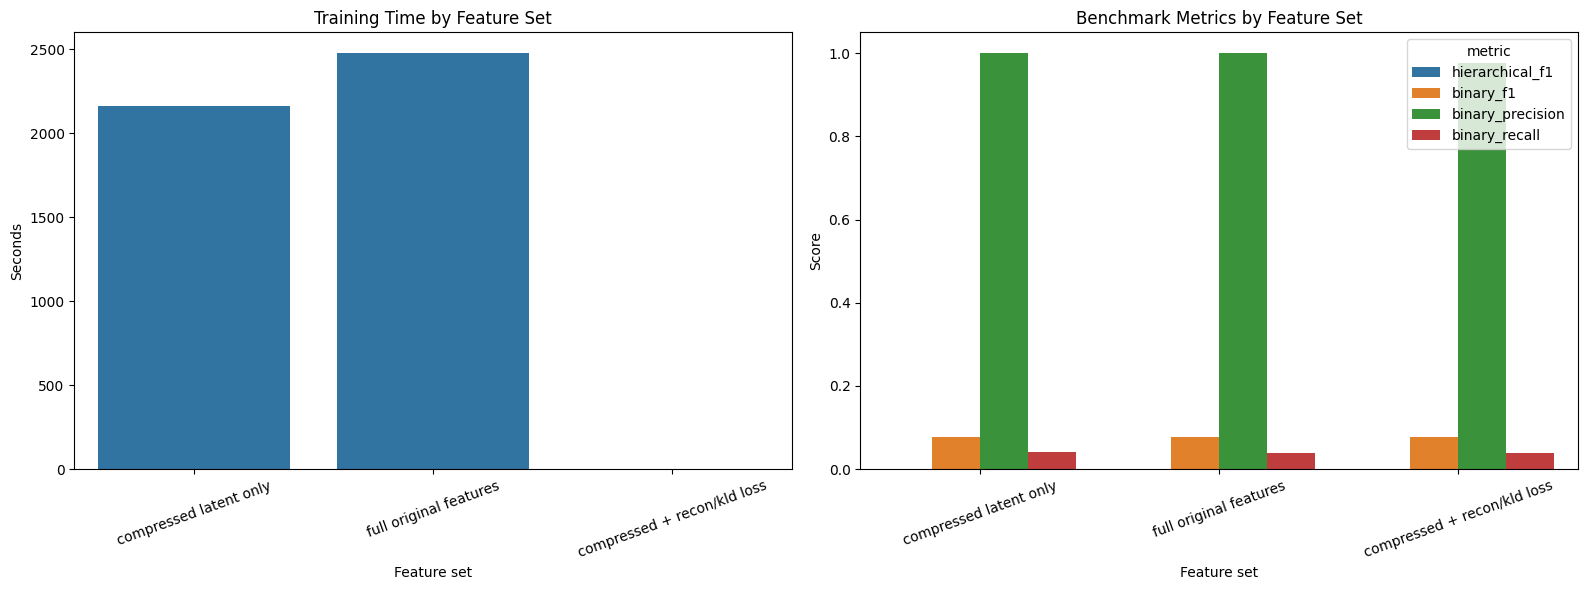

In [ ]:
# Save benchmark dataframes and generate comparison plot
ood_df = pd.DataFrame(ood_rows)
mc_df = pd.DataFrame(mc_rows)

print("OOD binary metrics:")
print(ood_df)
print("\nMulticlass in-dist metrics:")
print(mc_df)

ood_df.to_csv(artifact_path('catboost_ood_binary_metrics.csv'), index=False)
mc_df.to_csv(artifact_path('catboost_multiclass_metrics.csv'), index=False)
ood_df.to_csv(artifact_path('catboost_vae_ablation_ood_binary_metrics.csv'), index=False)
mc_df.to_csv(artifact_path('catboost_vae_ablation_multiclass_metrics.csv'), index=False)

metadata = {
    "variant_configs": VARIANT_CONFIGS,
    "experiments": list(experiment_results.keys()),
    "feature_sets_run": [
        {
            "experiment": row.get("experiment"),
            "variant": row.get("variant"),
            "feature_set": row.get("feature_set"),
            "train_file": row.get("train_file"),
            "final_ood_file": row.get("final_ood_file"),
            "n_features": row.get("n_features"),
        }
        for row in ood_rows
    ],
    "known_ood_constraint": "each final OOD CSV is loaded only inside run_final_ood_evaluation after that experiment trains and selects its threshold",
    "score_name_by_experiment": {
        name: "binary_head_domain_guarded" for name in experiment_results.keys()
    },
    "threshold_policy_by_experiment": {
        name: bundle["threshold_metrics"] for name, bundle in experiment_results.items()
    },
}

with open(artifact_path('catboost_experiment_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print("Saved catboost_ood_binary_metrics.csv")
print("Saved catboost_multiclass_metrics.csv")
print("Saved catboost_vae_ablation_ood_binary_metrics.csv")
print("Saved catboost_vae_ablation_multiclass_metrics.csv")
print("Saved catboost_experiment_metadata.json")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = ood_df.melt(
    id_vars=['feature_set', 'variant'],
    value_vars=['bal_acc', 'macro_f1', 'benign_specificity', 'attack_recall'],
    var_name='metric',
    value_name='score',
)
plot_df['experiment'] = plot_df['variant'] + " | " + plot_df['feature_set']
sns.barplot(data=plot_df, x='experiment', y='score', hue='metric', ax=axes[0])
axes[0].set_title('OOD Binary Metrics by Experiment')
axes[0].set_xlabel('Experiment')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='metric')

mc_plot_df = mc_df.melt(
    id_vars=['feature_set', 'variant'],
    value_vars=['bal_acc', 'macro_f1', 'hier_f1', 'subtype_f1'],
    var_name='metric',
    value_name='score',
)
mc_plot_df['experiment'] = mc_plot_df['variant'] + " | " + mc_plot_df['feature_set']
sns.barplot(data=mc_plot_df, x='experiment', y='score', hue='metric', ax=axes[1])
axes[1].set_title('Multiclass In-Dist Metrics by Experiment')
axes[1].set_xlabel('Experiment')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='metric')

plt.tight_layout()
plt.savefig(artifact_path('catboost_metrics_comparison.png'))
plt.close()
print("Saved catboost_metrics_comparison.png")
